In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pylab import *
mpl.rcParams['font.sans-serif'] = ['SimHei']

In [2]:
def analyze_significant_ladder_breakout(df, stock_name, lookback=60, sigma_multiplier=3.0):
    """
    显著阶梯式真突破算法
    逻辑：不仅要上涨，而且涨幅必须超过前一周的 1 倍标准差
    """
    df = df.copy()
    
    # --- 第一阶段：3-Sigma 极值 (大趋势红线) ---
    df['Rolling_Mean'] = df['Close'].rolling(window=lookback).mean()
    df['Rolling_Std'] = df['Close'].rolling(window=lookback).std()
    df['Upper_3Sigma'] = df['Rolling_Mean'] + (sigma_multiplier * df['Rolling_Std'])
    
    # --- 第二阶段：显著阶梯确认 (引入波动率滤网) ---
    # 1. 计算 5 日周均线和周标准差
    df['Weekly_MA'] = df['Close'].rolling(window=5).mean()
    df['Weekly_Std'] = df['Close'].rolling(window=5).std() # 代表每一周的“波动偏差”
    
    # 2. 提取三个时间点的 均值(W) 和 偏差(Std)
    # W1: 本周, W2: 上周, W3: 上前周
    df['W1'] = df['Weekly_MA']
    df['W2'] = df['Weekly_MA'].shift(5)
    df['W3'] = df['Weekly_MA'].shift(10)
    
    # 对应的偏差
    df['Std2'] = df['Weekly_Std'].shift(5) # 上周的波动
    df['Std3'] = df['Weekly_Std'].shift(10) # 上前周的波动
    
    # 3. 判定显著阶梯上涨：
    # 条件A：本周均值 > 上周均值 + 上周的1倍偏差
    # 条件B：上周均值 > 上前周均值 + 上前周的1倍偏差
    df['Significant_Up'] = (df['W1'] > (df['W2'] + 0.4* df['Std2'])) & \
                           (df['W2'] > (df['W3'] + 0.4* df['Std3']))
    
    # --- 第三阶段：最终信号 ---
    df['Price_Breakout'] = df['Close'] > df['Upper_3Sigma']
    # 必须同时满足：冲破大周期红线 + 连续两周显著(超额)上涨
    df['Final_Signal'] = df['Price_Breakout'] & df['Significant_Up']
    
    return df

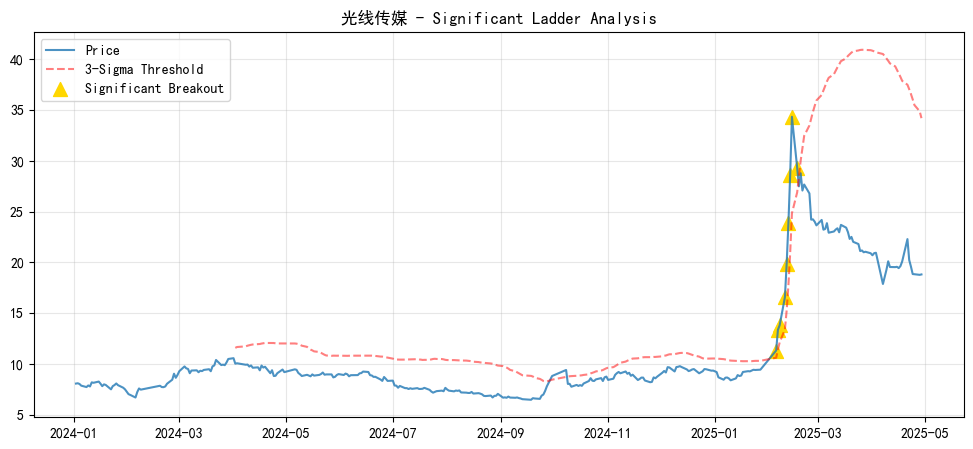

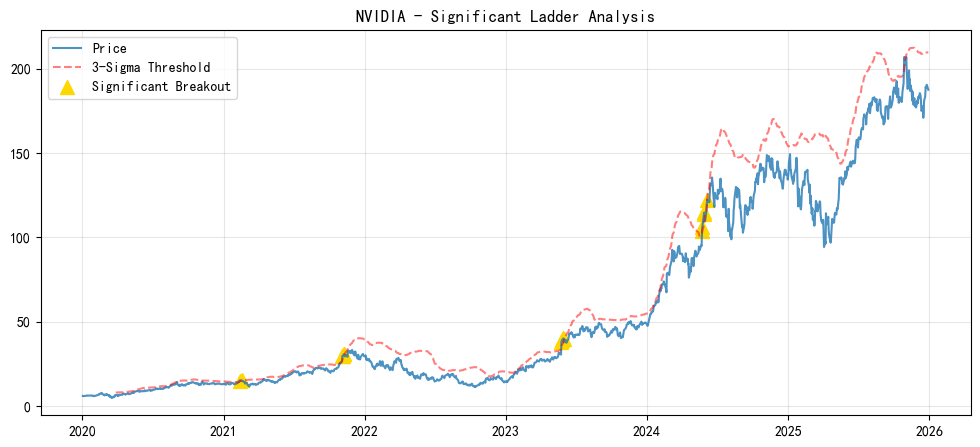

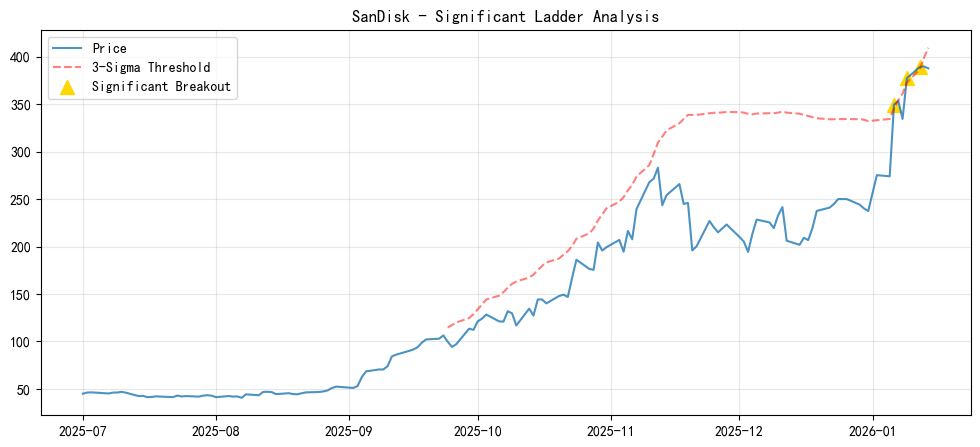


            显著阶梯式真突破筛选报告 (2026)
   股票名称   当前价格  3Sigma阈值    阶梯状态 真突破状态
   光线传媒  18.81     34.21 波动不足/回调   未达成
 NVIDIA 187.54    209.68 波动不足/回调   未达成
SanDisk 387.81    409.49    显著上涨   未达成


In [3]:
# --- 批量处理逻辑 ---
file_info = {
    "光线传媒": "../data/300251.csv",
    "NVIDIA": "../data/nvidia.csv",
    "SanDisk": "../data/sandisk_data.csv"
}

summary_list = []

for stock_name, path in file_info.items():
    if not os.path.exists(path): continue
    
    df_raw = pd.read_csv(path)
    df_raw['Date'] = pd.to_datetime(df_raw['Date'])
    df_raw.set_index('Date', inplace=True)
    
    res = analyze_significant_ladder_breakout(df_raw, stock_name)
    last = res.iloc[-1]
    
    summary_list.append({
        "股票名称": stock_name,
        "当前价格": round(last['Close'], 2),
        "3Sigma阈值": round(last['Upper_3Sigma'], 2),
        "阶梯状态": "显著上涨" if last['Significant_Up'] else "波动不足/回调",
        "真突破状态": "已达成" if last['Final_Signal'] else "未达成"
    })

    # 绘图
    plt.figure(figsize=(12, 5))
    plt.plot(res.index, res['Close'], label='Price', alpha=0.8)
    plt.plot(res.index, res['Upper_3Sigma'], 'r--', label='3-Sigma Threshold', alpha=0.5)
    
    # 标记信号点
    signals = res[res['Final_Signal']]
    plt.scatter(signals.index, signals['Close'], color='gold', marker='^', s=100, label='Significant Breakout')
    
    plt.title(f"{stock_name} - Significant Ladder Analysis")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    

print("\n" + "="*60)
print("            显著阶梯式真突破筛选报告 (2026)")
print("="*60)
print(pd.DataFrame(summary_list).to_string(index=False))